=== WYNIKI OBLICZEŃ DLA WARIANTU 11 ===
Środek danych (X, Y): (1.0098, 1.4832)
Oś główna 1 (wektor kierunkowy): [-0.6992, 0.7150]
Oś główna 2 (wektor kierunkowy): [0.7150, 0.6992]
Kąt obrotu: 2.3450 radianów (co daje ok. 134.36 stopni)



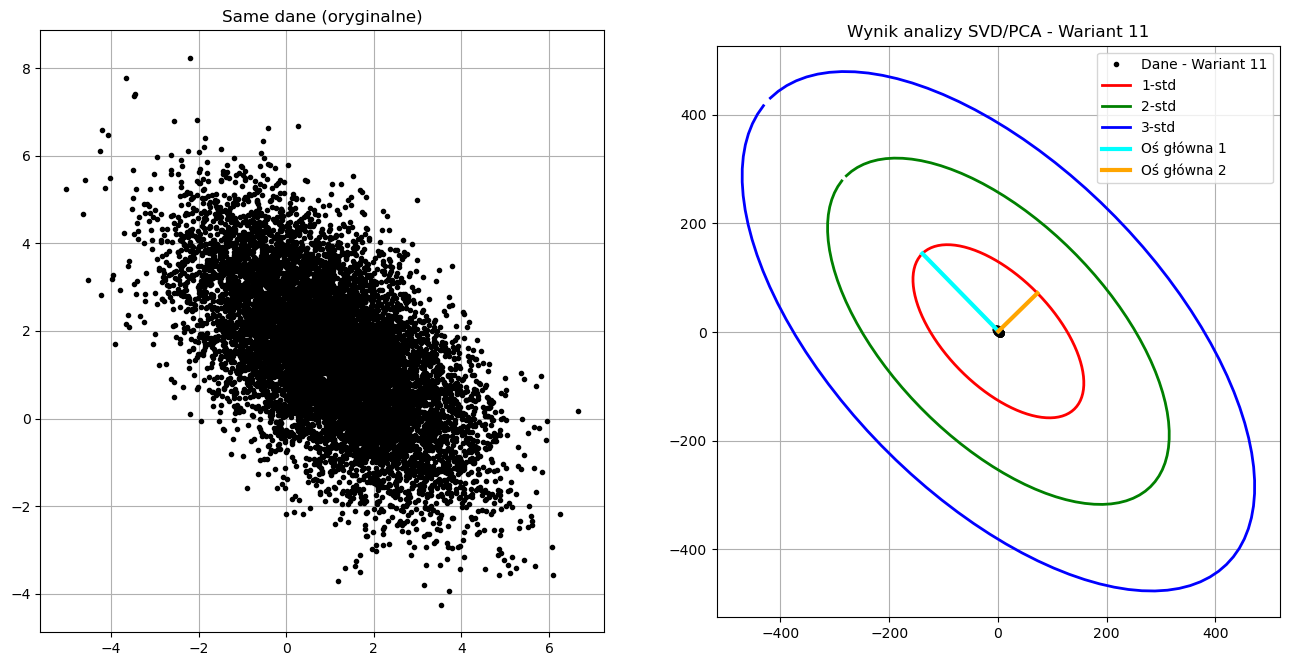

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('11.csv', delimiter=',')

# Dopasowanie kształtu - oczekujemy macierzy o wymiarach 2 x N (X[0,:] oraz X[1,:])
if len(data.shape) == 1:
    X = data.reshape(2, -1)
elif len(data.shape) == 2 and data.shape[1] == 2:
    X = data.T
else:
    X = data

# 2. Obliczenia statystyczne i SVD
Xavg = np.mean(X, axis=1)

B = X - Xavg.reshape(-1, 1)

# Wykonanie dekompozycji SVD na wycentrowanych danych
U, S, VT = np.linalg.svd(B, full_matrices=False)

print("=== WYNIKI OBLICZEŃ DLA WARIANTU 11 ===")

print(f"Środek danych (X, Y): ({Xavg[0]:.4f}, {Xavg[1]:.4f})")

os_glowna_1 = U[:, 0]
os_glowna_2 = U[:, 1]
print(f"Oś główna 1 (wektor kierunkowy): [{os_glowna_1[0]:.4f}, {os_glowna_1[1]:.4f}]")
print(f"Oś główna 2 (wektor kierunkowy): [{os_glowna_2[0]:.4f}, {os_glowna_2[1]:.4f}]")

kat_rad = np.arctan2(os_glowna_1[1], os_glowna_1[0])
kat_stopnie = np.degrees(kat_rad)
print(f"Kąt obrotu: {kat_rad:.4f} radianów (co daje ok. {kat_stopnie:.2f} stopni)")
print("=======================================\n")

#fig = plt.figure(figsize=(8, 8))
#ax2 = fig.add_subplot(111)

fig = plt.figure(figsize=(16, 8))

ax1 = fig.add_subplot(121)
ax1.plot(X[0, :], X[1, :], '.', color='k')
ax1.grid()
ax1.set_aspect('equal', 'box')
ax1.set_title('Same dane (oryginalne)')

# Drugi wykres z elipsami i osiami SVD (po prawej)
ax2 = fig.add_subplot(122) # Zmiana z 111 na 122

# Narysowanie punktów reprezentujących surowe dane
ax2.plot(X[0, :], X[1, :], '.', color='k', label='Dane - Wariant 11')
ax2.grid()

theta = 2 * np.pi * np.arange(0, 1, 0.01)

Xstd = U @ np.diag(S) @ np.array([np.cos(theta), np.sin(theta)])

ax2.plot(Xavg[0] + Xstd[0, :], Xavg[1] + Xstd[1, :], '-', color='r', linewidth=2, label='1-std')
ax2.plot(Xavg[0] + 2*Xstd[0, :], Xavg[1] + 2*Xstd[1, :], '-', color='g', linewidth=2, label='2-std')
ax2.plot(Xavg[0] + 3*Xstd[0, :], Xavg[1] + 3*Xstd[1, :], '-', color='b', linewidth=2, label='3-std')

# Rysowanie głównych składowych (wektorów rozpinających wariancję)
# Pierwsza składowa (PC1)
ax2.plot([Xavg[0], Xavg[0] + U[0,0]*S[0]], 
         [Xavg[1], Xavg[1] + U[1,0]*S[0]], 
         '-', color='cyan', linewidth=3, label='Oś główna 1')

# Druga składowa (PC2)
ax2.plot([Xavg[0], Xavg[0] + U[0,1]*S[1]], 
         [Xavg[1], Xavg[1] + U[1,1]*S[1]], 
         '-', color='orange', linewidth=3, label='Oś główna 2')

# Wyrównanie proporcji osi i dodanie legendy
ax2.set_aspect('equal', 'box')
plt.legend()
plt.title('Wynik analizy SVD/PCA - Wariant 11')
plt.show()